In [70]:
import matplotlib
import matplotlib.pyplot as plt

IS_ONLINE_JUDGE = False

# =================================
import time

GLOBAL_START_TIME = time.perf_counter()


def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")


# =================================
import heapq
import math
from functools import lru_cache

import numpy as np
from shapely.geometry import LineString, Point, Polygon
from shapely.ops import split

INF = 10**18
ESTIMATE_MAX_TIME = 1.28

N_POINT = 90
N_PAIR = 40
CUT_RATIO = 0.01

FILE_NUM = 1
TARGET_LENGTH = 1500


# =================================
def calc_rectangle_area(rectangle):
    l, r, t, b = rectangle
    area = (r - l) * (b - t)
    return area


def calc_dist(p1: tuple, p2: tuple) -> float:
    return math.dist(p1, p2)


def fast_greedy_pairing(points: list[tuple[float, float]]) -> list[tuple[int, int]]:
    n = len(points)
    used = [False] * n
    pairs = []

    heaps = []
    for i in range(n):
        heap = []
        for j in range(n):
            if i != j:
                dist_sq = calc_dist(points[i], points[j])
                heapq.heappush(heap, (dist_sq, j))
        heaps.append(heap)

    for i in range(n):
        if used[i]:
            continue
        while heaps[i]:
            _, j = heapq.heappop(heaps[i])
            if not used[j]:
                pairs.append((i, j))
                used[i] = used[j] = True
                break

    return pairs


def target_length_pairing(
    points: list[tuple[float, float]], target_length: float = TARGET_LENGTH
) -> list[tuple[int, int]]:
    n = len(points)
    used = [False] * n
    pairs = []

    heaps = []
    for i in range(n):
        heap = []
        for j in range(n):
            if i != j:
                dist_val = calc_dist(points[i], points[j])
                score = abs(dist_val - target_length)  # 目標距離との差をスコアにする
                heapq.heappush(heap, (score, j))
        heaps.append(heap)

    for i in range(n):
        if used[i]:
            continue
        while heaps[i]:
            _, j = heapq.heappop(heaps[i])
            if not used[j]:
                pairs.append((i, j))
                used[i] = used[j] = True
                break

    return pairs


def farthest_point_sampling(points: np.ndarray, M: int) -> np.ndarray:
    N = len(points)
    selected_indices = []

    idx = np.random.randint(0, N)
    selected_indices.append(idx)
    min_distances = np.full(N, np.inf)

    for _ in range(1, M):
        last_point = points[selected_indices[-1]]
        distances = np.linalg.norm(points - last_point, axis=1)
        min_distances = np.minimum(min_distances, distances)
        next_idx = np.argmax(min_distances)
        selected_indices.append(int(next_idx))

    return selected_indices


def select_pairs(cneter_points, rectangles):
    diffs = []
    for v, (l, r, t, b) in enumerate(rectangles):
        diffs.append((v, abs(l - r) + abs(t - b)))

    sorted_diffs = sorted(diffs, key=lambda x: x[1])

    target_diffs = sorted_diffs[:N_POINT]
    target_inds = [diff[0] for diff in target_diffs]
    target_points = [cneter_points[diff[0]] for diff in target_diffs]
    pairs = target_length_pairing(target_points)
    pairs = [(target_inds[i], target_inds[j]) for i, j in pairs]
    pair_centers = []
    for v, q in pairs:
        pair_centers.append(
            ((cneter_points[v][0] + cneter_points[q][0]) / 2, (cneter_points[v][1] + cneter_points[q][1]) / 2)
        )
    sample_inds = farthest_point_sampling(np.array(pair_centers), N_PAIR)
    selected_pairs = []
    for i in sample_inds:
        selected_pairs.append(pairs[i])
    return selected_pairs


def split_polygon_with_extended_line(polygon, cut_string) -> list[Polygon]:
    result = split(polygon, cut_string)
    polygons = [geom for geom in result.geoms if isinstance(geom, Polygon)]
    return polygons


@lru_cache(maxsize=None)
def extend_line_fixed_bounds(cut_string: LineString, bounds_min=-20000, bounds_max=20000):
    # ベクトルの方向を正規化
    cut_point1, cut_point2 = cut_string.coords
    p1 = np.array(cut_point1)
    p2 = np.array(cut_point2)
    direction = p2 - p1
    direction = direction / np.linalg.norm(direction)

    # 直線の延長距離を大きくとる
    length = (bounds_max - bounds_min) * 2
    new_p1 = p1 - direction * length
    new_p2 = p2 + direction * length

    return LineString([new_p1, new_p2])


@lru_cache(maxsize=None)
def perpendicular_bisector(point1, point2):
    """
    垂直二等分線
    """
    p1 = np.array(point1)
    p2 = np.array(point2)

    midpoint = (p1 + p2) / 2
    vec = p2 - p1
    norm = np.linalg.norm(vec)
    perp_vec = np.array([-vec[1], vec[0]]) / norm
    start = midpoint - perp_vec
    end = midpoint + perp_vec

    return LineString([start, end])


@lru_cache(maxsize=None)
def create_my_custom_rect(point1, point2):
    """
    point1とpoint2を結ぶ線分と直角に交わる線分を利用して正方形を作る
    """
    p1 = np.array(point1)
    p2 = np.array(point2)

    vec = p2 - p1
    perp_vec = np.array([-vec[1], vec[0]]) / 2
    square_points = [
        tuple(p1 - perp_vec),
        tuple(p1 + perp_vec),
        tuple(p2 + perp_vec),
        tuple(p2 - perp_vec),
    ]
    # square_points = sorted(square_points, key=lambda x: (x[0], x[1]))

    return Polygon(square_points)


class MyPolygon:
    BIG_POLYGON = Polygon([(0, 0), (0, 10000), (10000, 10000), (10000, 0)])

    def __init__(self, rect_points, ind):
        l, r, t, b = rect_points
        points = [
            (l, t),
            (r, t),
            (r, b),
            (l, b),
        ]
        self.polygon = Polygon(points)
        self.ind = ind

    def area(self):
        return self.polygon.area

    def is_cutting(self, cut_point1, cut_point2):
        cut_string = extend_line_fixed_bounds(perpendicular_bisector(cut_point1, cut_point2))
        if self.polygon.crosses(cut_string):
            d_p1 = self.polygon.exterior.distance(Point(cut_point1))
            d_p2 = self.polygon.exterior.distance(Point(cut_point2))
            d_p12 = calc_dist(cut_point1, cut_point2)
            if (d_p1 < d_p12) and (d_p2 < d_p12):
                return False
            # custom_rect = create_my_custom_rect(cut_point1, cut_point2)
            result_polygons = split_polygon_with_extended_line(self.polygon, cut_string)
            if len(result_polygons) == 2:  # and (not self.polygon.intersects(custom_rect)):
                return min(result_polygons[0].area, result_polygons[1].area)
        return False

    def cut(self, cut_point1, cut_point2, target_cut):
        cut_string = extend_line_fixed_bounds(perpendicular_bisector(cut_point1, cut_point2))
        result_polygons = split_polygon_with_extended_line(self.polygon, cut_string)
        splited_big_polygons = split_polygon_with_extended_line(MyPolygon.BIG_POLYGON, cut_string)
        r1 = result_polygons[0].centroid
        b1 = splited_big_polygons[0]
        b2 = splited_big_polygons[1]
        if b1.intersects(Point(target_cut)):
            if b1.intersects(r1):
                self.polygon = result_polygons[0]
            else:
                self.polygon = result_polygons[1]
        else:
            if b2.intersects(r1):
                self.polygon = result_polygons[0]
            else:
                self.polygon = result_polygons[1]


def prim(
    graph: dict[int, list[tuple[int, int]]],
) -> tuple[list[tuple[int, int]], list[int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(graph.keys())
    used = {v: False for v in v_list}

    init_v = v_list[0]  # 適当な点を選ぶ
    used[init_v] = True
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v: list[int] = [init_v]
    ans_edges: list[tuple[int, int]] = []
    while que:
        cost_v, from_v, to_v = heapq.heappop(que)
        if used[to_v]:
            continue
        used[to_v] = True
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        for nxt, cost_nxt in graph[to_v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v


def prim_k(graph: list[list[float]], init_v: int, k: int, used_v: set[int], N):
    """
    init_vを含むk頂点の最小全域木を求める
    """
    used = used_v | {init_v}
    used.add(init_v)
    que = [(graph[init_v][v], init_v, v) for v in range(N)]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    ans_cost = 0.0
    while que and len(ans_v) < k:
        cost_v, from_v, to_v = heapq.heappop(que)
        if to_v in used:
            continue
        used.add(to_v)
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        ans_cost += cost_v
        for nxt in range(N):
            if nxt in used:
                continue
            heapq.heappush(que, (graph[to_v][nxt], to_v, nxt))
    return ans_edges, ans_v, ans_cost


# =================================


class EnvOffline:
    def __init__(self, input_file_path: str, output_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(tuple(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]
        self._query_history: list[str] = []

        self.input_file_path = input_file_path
        self.output_file_path = output_file_path

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = abs(x1 - x2) ** 2 + abs(y1 - y2) ** 2
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        cost = 0.0
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
                dist = calc_dist(self.coordinates[e[0]], self.coordinates[e[1]])
                cost += dist

        for query_str in self._query_history:
            ans_str += query_str + "\n"

        with open(self.output_file_path, "w") as f:
            f.write(ans_str)

        return cost


class EnvOnline:
    def __init__(self):
        N, M, Q, L, W = map(int, input().split())
        G = list(map(int, input().split()))
        rectangles = []
        for l in range(N):
            rectangles.append(list(map(int, input().split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        print(query_str)
        return [tuple(map(int, input().split())) for _ in range(len(c_list) - 1)]

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
        print(ans_str)


def estimate_coordinate(env: EnvOnline):
    start_time = time.perf_counter()
    selected_pairs = select_pairs(env.cneter_points, env.rectangles)
    selected_pair_coordinates = []
    for i, j in selected_pairs:
        selected_pair_coordinates.append((i, j, env.cneter_points[i], env.cneter_points[j]))

    polygon_heap = []
    my_polygons: dict[int, MyPolygon] = {}
    for v, (l, r, t, b) in enumerate(env.rectangles):
        polygon_heap.append((-calc_rectangle_area(env.rectangles[v]), v))
        my_polygons[v] = MyPolygon(env.rectangles[v], v)
    heapq.heapify(polygon_heap)

    cut_num = 0
    not_cut_num = 0
    while polygon_heap and cut_num < 400:
        if time.perf_counter() - start_time >= ESTIMATE_MAX_TIME:
            break
        poly_area, poly_ind = heapq.heappop(polygon_heap)
        poly = my_polygons[poly_ind]
        max_area = 0
        cut_pair = None
        for p1, p2, c1, c2 in selected_pair_coordinates:
            cutting_area = poly.is_cutting(c1, c2)
            if cutting_area:
                if cutting_area > max_area:
                    max_area = cutting_area
                    cut_pair = (p1, p2, c1, c2)
        if cut_pair and max_area > CUT_RATIO * -poly_area:
            cut_num += 1
            p1, p2, c1, c2 = cut_pair
            q = env.query([p1, p2, poly.ind])
            q_vs = list(q[0]) + list(q[1])
            if q_vs.count(p1) == 2:
                target_cut = c1, p1
            elif q_vs.count(p2) == 2:
                target_cut = c2, p2
            else:
                not_cut_num += 1
                custom_rect = create_my_custom_rect(c1, c2)
                print(custom_rect.overlaps(poly.polygon))
                print(custom_rect.intersects(poly.polygon))
                print(poly.polygon.overlaps(custom_rect))
                print(poly.polygon.intersects(custom_rect))
                plt.figure(figsize=(10, 10))
                plt.xlim(0, 10000)
                plt.ylim(0, 10000)
                plt.gca().set_aspect("equal")
                plt.plot(*poly.polygon.exterior.xy, color="black")
                # custom_rectを描画
                plt.plot(*custom_rect.exterior.xy, color="green")
                print(custom_rect.exterior.coords)
                plt.scatter(*c1, marker="o", color="red")
                plt.scatter(*c2, marker="o", color="red")
                plt.scatter(*env.coordinates[poly.ind], marker="o", color="blue")
                plt.show()
                print(c1, p1, c2, p2, poly.ind, env.coordinates[poly.ind])
                print(q)
                print(c1, p1, c2, p2, poly.ind, env.coordinates[poly.ind])
                continue
            poly.cut(c1, c2, target_cut[0])
            # print(poly.ind, p1, p2, target_cut)
            new_poly_area = poly.area()
            my_polygons[poly_ind] = poly
            heapq.heappush(polygon_heap, (-new_poly_area, poly_ind))
    debug_print(f">cutting: {cut_num - not_cut_num}/{cut_num}")

    estimate_coordinate = []
    for n in range(env.N):
        x, y = my_polygons[n].polygon.centroid.xy
        estimate_coordinate.append((x[0], y[0]))
    return estimate_coordinate


def solve(env: EnvOffline, target_points):
    graph: list[list[float]] = [[0 for _ in range(env.N)] for _ in range(env.N)]
    for i in range(env.N):
        for j in range(env.N):
            if i == j:
                continue
            dist = calc_dist(target_points[i], target_points[j])
            graph[i][j] = dist
            graph[j][i] = dist

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges


def main():
    if IS_ONLINE_JUDGE:
        env = EnvOnline()
        target_coodinates = estimate_coordinate(env)
        ans_v, ans_edges = solve(env, target_coodinates)
        env.answer(ans_v, ans_edges)
    else:
        costs = []
        for file_num in range(FILE_NUM):
            start_time = time.perf_counter()
            input_file_path = f"../in/{file_num:04d}.txt"
            output_file_path = f"../out/{file_num:04d}.txt"
            env = EnvOffline(input_file_path, output_file_path)
            target_coodinates = estimate_coordinate(env)
            ans_v, ans_edges = solve(env, target_coodinates)
            cost = env.answer(ans_v, ans_edges)
            debug_print(f"[{file_num}/{FILE_NUM}]: {cost} {time.perf_counter() - start_time:.2f}s")
            costs.append(cost)
        debug_print(f"avg: {sum(costs) / len(costs)}")
        debug_print(f"max: {max(costs)}")
        with open("../out/costs.txt", "w") as f:
            for cost in costs:
                f.write(f"{cost}\n")


if __name__ == "__main__":
    main()


>cutting: 400/400
[0/1]: 300246.7150007301 1.19s
avg: 300246.7150007301
max: 300246.7150007301


In [71]:
p1 = (6133.0, 525.0)
p2 = (816.5, 927.5)

p1 = np.array(p1)
p2 = np.array(p2)

midpoint = (p1 + p2) / 2
vec = p2 - p1
norm = np.linalg.norm(vec)
perp_vec = np.array([-vec[1], vec[0]]) / 2
square_points = [
    tuple(p1 - perp_vec),
    tuple(p1 + perp_vec),
    tuple(p2 + perp_vec),
    tuple(p2 - perp_vec),
]

square_points

[(np.float64(6334.25), np.float64(3183.25)),
 (np.float64(5931.75), np.float64(-2133.25)),
 (np.float64(615.25), np.float64(-1730.75)),
 (np.float64(1017.75), np.float64(3585.75))]

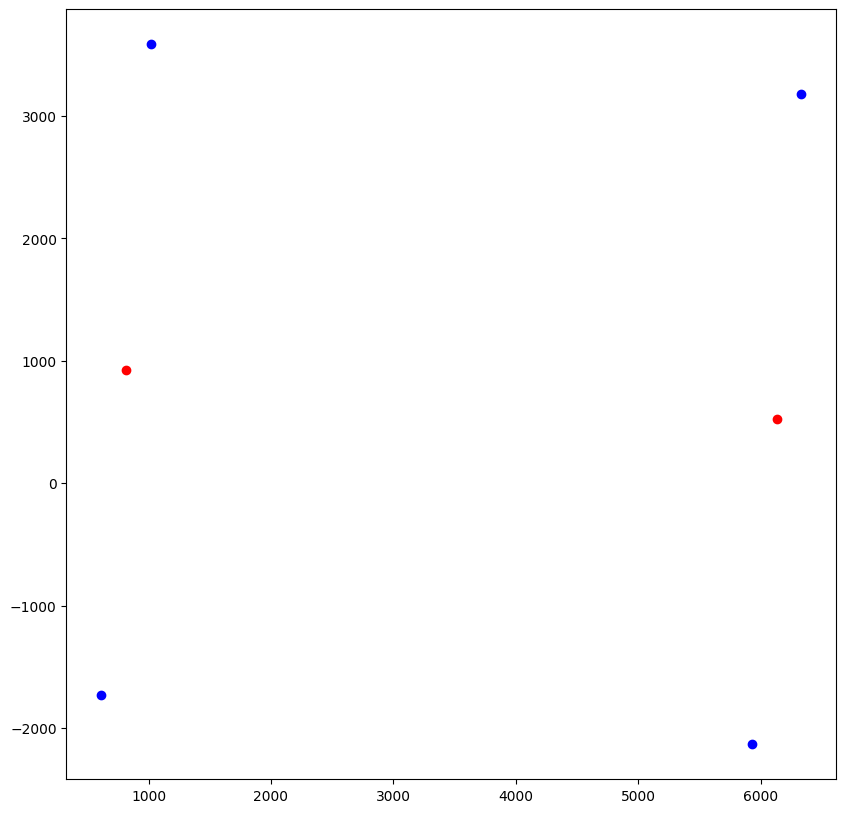

In [72]:
# square_pointsを四角形で描画
plt.figure(figsize=(10, 10))
plt.gca().set_aspect("equal")
x, y = zip(*square_points)
plt.scatter(x, y, marker="o", color="blue")
plt.scatter(*p1, marker="o", color="red")
plt.scatter(*p2, marker="o", color="red")
plt.show()


In [73]:
perp_vec

array([ -201.25, -2658.25])